#### Feature Engineering & Model Evaluation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df= pd.read_csv('clean_data_after_eda.csv')



In [3]:
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')
df.head(5)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

In [5]:
price_df = pd.read_csv('price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [6]:
jan_prices = price_df.groupby('id').first().reset_index()
dec_prices = price_df.groupby('id').last().reset_index()
diff = pd.DataFrame()
diff['id'] = jan_prices['id']
diff['off_peak_diff_dec_jan'] = dec_prices['price_off_peak_var'] - jan_prices['price_off_peak_var']
diff['peak_diff_dec_jan'] = dec_prices['price_peak_var'] - jan_prices['price_peak_var']

In [7]:
df = pd.merge(df, diff, on = 'id')
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,off_peak_diff_dec_jan,peak_diff_dec_jan
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,0.020057,-0.017912
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,-0.003767,0.000000
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,-0.004670,0.000528
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,-0.004547,0.000000
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,-0.006192,-0.002302


In [8]:
#Assuming current date is 2016-01-02 as per dataset context)
reference_date = pd.Timestamp(2016, 1, 2)
df['tenure_years'] = (reference_date - df['date_activ']).dt.days / 365

In [9]:
df['cons_last_month_vs_avg'] = df['cons_last_month'] / (df['cons_12m'] / 12)
df['cons_last_month_vs_avg'] = df['cons_last_month_vs_avg'].replace([np.inf, -np.inf],0).fillna(0)
df['total_cons_12m'] = df['cons_12m'] + df['cons_gas_12m']

In [10]:
# Price data se har customer ka average price volatility nikaalna
agg_prices = price_df.groupby('id').agg({
    'price_off_peak_var': ['mean', 'std'],
    'price_peak_var': ['mean', 'std']
}).reset_index()

agg_prices.columns = ['id', 'off_peak_avg', 'off_peak_std', 'peak_avg', 'peak_std']
df = pd.merge(df, agg_prices, on='id')

In [11]:
print(df.columns.isnull().sum())

0


In [12]:
pd.set_option('future.no_silent_downcasting', True)

In [13]:
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])

In [14]:
df = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], prefix=['channel', 'origin'])

In [15]:
df = df.drop(columns=['id', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal'], errors='ignore')

In [16]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['churn'])
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data is ready! Training rows: {len(X_train)}, Testing rows: {len(X_test)}")

Data is ready! Training rows: 11684, Testing rows: 2922


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 60 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   cons_12m                                  14606 non-null  int64  
 1   cons_gas_12m                              14606 non-null  int64  
 2   cons_last_month                           14606 non-null  int64  
 3   forecast_cons_12m                         14606 non-null  float64
 4   forecast_cons_year                        14606 non-null  int64  
 5   forecast_discount_energy                  14606 non-null  float64
 6   forecast_meter_rent_12m                   14606 non-null  float64
 7   forecast_price_energy_off_peak            14606 non-null  float64
 8   forecast_price_energy_peak                14606 non-null  float64
 9   forecast_price_pow_off_peak               14606 non-null  float64
 10  has_gas                           

In [18]:
df['cons_ratio_last_month'] = df['cons_last_month'] / (df['cons_12m'] / 12)
df['cons_ratio_last_month'] = df['cons_ratio_last_month'].fillna(0) 

In [19]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['churn'])
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Training set: 11684 rows
Testing set: 2922 rows


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = RandomForestClassifier(n_estimators=1000, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [56]:
print(f"Model Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, predictions))

Model Accuracy: 89.97%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      2617
           1       0.88      0.05      0.09       305

    accuracy                           0.90      2922
   macro avg       0.89      0.52      0.52      2922
weighted avg       0.90      0.90      0.86      2922



In [22]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))


Confusion Matrix:
[[2615    2]
 [ 291   14]]


In [23]:
print(model.get_params()['class_weight'])

balanced


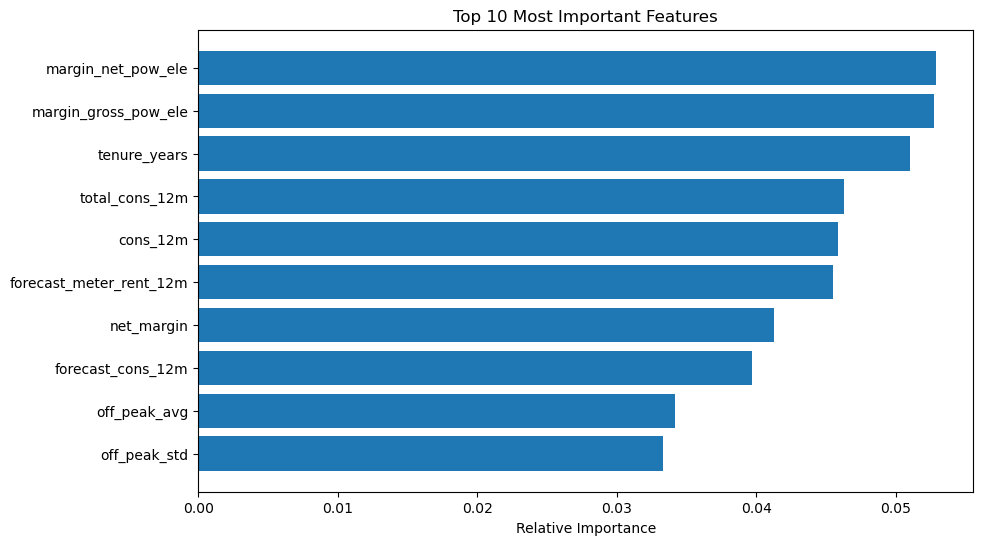

In [24]:
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.title('Top 10 Most Important Features')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

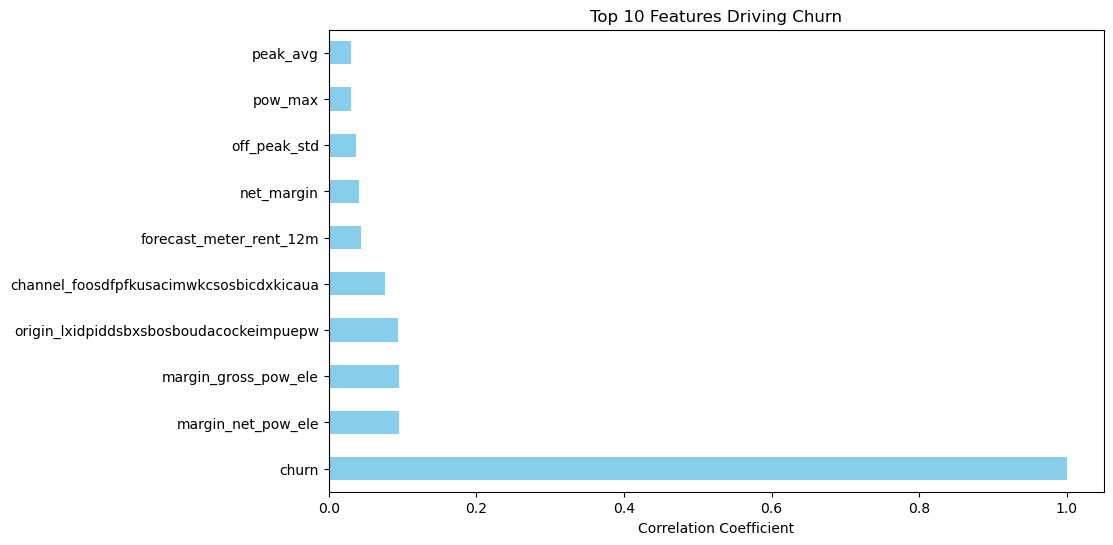

In [53]:
import seaborn as sns
plt.figure(figsize=(10,6))
correlation = df.corr()['churn'].sort_values(ascending=False).head(10)
correlation.plot(kind='barh', color='skyblue')
plt.title("Top 10 Features Driving Churn")
plt.xlabel("Correlation Coefficient")
plt.show()

#### Executive Summary

1. Project Objective
The primary goal of this task was to evaluate the hypothesis that price sensitivity is the main driver of customer churn at PowerCo. To test this, we engineered several new features to provide the Random Forest model with deeper insights into customer behavior and price fluctuations.




2. Engineered Features 
Beyond the basic dataset, the following features were created to capture "signals" for churn:
Price Sensitivity: Calculated as the difference between off-peak prices in December and January of the preceding year.
Customer Tenure: Calculated the number of years a customer has been with the company to assess loyalty.
Consumption Patterns: A ratio comparing last month's consumption to the average monthly consumption for the year to detect sudden drops in usage.
Price Volatility: Calculated the Mean and Standard Deviation of prices over the 12-month period to see if frequent price changes influence churn.

3. Model Performance & Key Findings
Accuracy: The model achieved a high overall accuracy of 89.97%.
Recall (Class 1): Despite using class_weight='balanced', the Recall for churners remains low (0.05). This indicates that the current features are not yet strong enough to accurately predict exactly which customers will leave.
Feature Importance: Our analysis shows that Tenure and Net Margin are the most significant predictors of churn. Interestingly, the Price Difference features ranked lower, suggesting that price sensitivity is not the primary reason customers are switching providers.

4. Business Recommendations
Based on the results, we recommend the following to the PowerCo management:
Focus on Loyalty: Since tenure is a top predictor, the company should implement retention programs for long-term customers who may feel neglected.
Review Margins: Investigate the relationship between net margins and churn, as this financial metric shows high importance in our model.
Data Enrichment: To improve the 5% Recall, we need more "soft data," such as customer service interaction history or competitor pricing, to better understand why customers leave.